# 합성곱 신경망(CNN)
- 합성곱신경망(Convolutional Neural Networks, CNN)은 주로 이미지 인식, 영상 분석, 객체 탐지 등 시각적 데이터를 처리
하는 데 탁월한 성능을 보이는 딥러닝 모델
    - CNN은 신경망이 데이터의 공간적 구조를 인식하고, 이를 기반으로 특징을 학습할 수 있도록 설계
- CNN은 DNN과는 다르게, 이미지나 영상과 같은 데이터를 처리할 때의 효율성을 높이고 성능을 향상시키기 위해 합성곱 층
(Convolutional Layer), 풀링 층 (Pooling Layer), 완전연결 층 (Fully Connected Layer)을 가짐

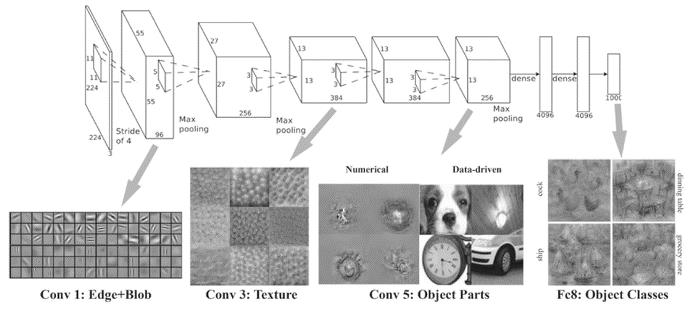

## 합성곱 층(Convolutional Layer, Conv)
- 합성곱 층(Convolutional Layer)은 합성곱 신경망의 핵심 구성 요소로, 이미지와 같은 데이터에서 유용한 특징을 추출하는 역할을 하며 입력 데이터에 커널을 적용하여 합성곱 연산을 수행함으로써 특징 맵(feature map)을 생성
    - 데이터의 공간적 구조를 유지하면서 유의미한 패턴(예: 가장자리, 질감 등)을 학습
    - 커널(필터)이 학습 파라미터
- 커널을 입력 이미지의 좌측 상단부터 우측 하단까지 슬라이딩하며 입력 이미지의 한 부분과 겹칠 때마다 두 행렬 간의 요소별 곱셈을 수행한 후, 그 결과를 모두 더하여 출력 값으로 사용
    - 커널은 작은 크기의 행렬(1x1, 3x3, 5x5, 7x7 등)로 구성
    - 커널은 특정 패턴을 인식하는 역할
- 특징 맵 크기 계산
- 대칭성을 위해 보통 커널의 크기는 3x3, 5x5, 7x7등 홀수로 많이 지정
- 3x3은 작은 지역의 공간적 패턴을 학습하여 이미지의 특징을 추출하고, 국소적인 정보를 포착하는 데 효과적
    - CNN에서 가장 많이 사용되는 필터 크기
- 1x1은 채널 간 상호작용을 통해 차원 축소 및 비선형 변환을 수행하며, 연산량을 줄이면서도 표현력을 높이는 데 사용
- 28, 28 이미지에 3x3 커널, 스트라이드는 1을 적용하는 경우 특징 맵의 크기는 다음과 같음
    - padding = 'valid' <br>
$\text{Output_size} = [\frac{\text{Input_size} - \text{kernel_size}}{Stride}] + 1 = [\frac{28 - 3}{1}] + 1 = 26$
    - padding = 'same' <br>
$\text{Output_size} = [\frac{\text{Input_size} - 1}{Stride}] + 1 = [\frac{28 - 1}{1}] + 1 = 28$
- Conv 레이어 사용
```
tf.keras.layers.Conv2D(filters, kernel_size, strides=(1, 1),padding='valid')
```
    - `filters` : 뉴런의 개수
    - `kernel_size` : 합성곱을 진행할 커널(필터)의 사이즈
    - `strides` : 이동 간격
    - `padding` : 가장자리 보정 여부('valid' 보정 없음, 'same' 가장자리에 0을 추가)

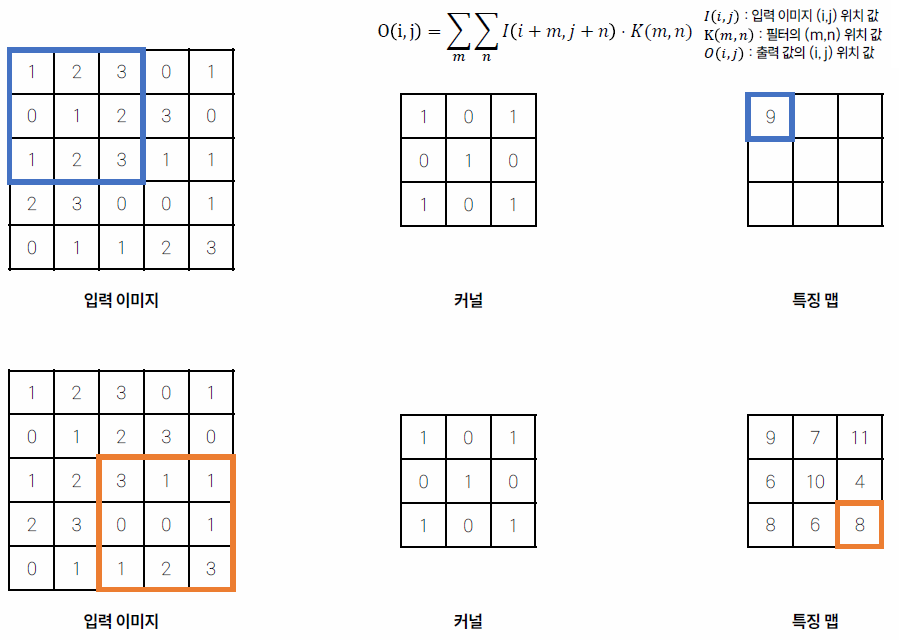

In [ ]:
# padding = 'valid' -> 패딩 사용하지 않겠다
# padding = 'same' -> 이미지의 크기 유지시켜줄 수 있게 패딩 사용
# kernel_size와 Stride에 따라 달라져 Stride가 커지면 커질수록 이동을 크게 하기때문에 작아짐
# [I - K + 2P / S] + 1 ?
# padding : 가장자리 값 중요할 떄 Stride는 1을 많이 사용 Kernel 은 3X3,5X5 많이 사용

### 패딩(padding)
- CNN의 초기 합성곱 층에서 커널(필터)은 일반적으로 저수준의 특징(예: 선, 가장자리, 텍스처)을 학습하며 신경망이 깊어질수록 커널(필터)은 더 고수준의 특징(예: 객체의 일부분, 얼굴 등)을 학습
- 합성곱 연산의 결과로 출력 특징 맵의 크기가 줄어드는 것을 방지하거나, 특정한 출력 크기를 유지하기 위해 패딩을 사용
    - 패딩은 입력 이미지의 가장자리에 추가적인 픽셀(0)을 채워 넣는 작업
    - 출력 특징 맵의 크기를 입력 이미지와 동일하게 유지하고자 할 때 사용(`padding='same'`)

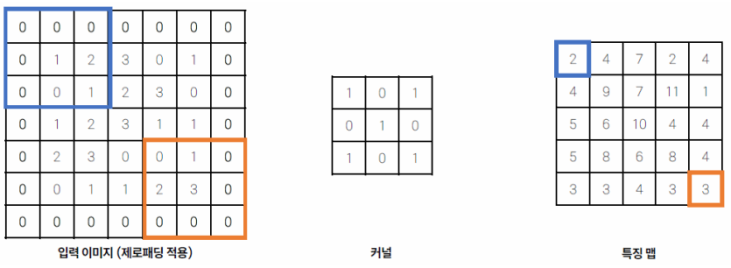

### 스트라이드(Stride)
- 필터가 입력 이미지 위를 이동하는 간격을 의미
- 기본값으로 스트라이드는 1로 설정되어 있어 필터가 한 번에 한 픽셀씩 이동
    - 스트라이드를 2로 설정하면 필터는 한 번에 두 픽셀씩 이동하므로 출력 특징 맵의 크기가 더 작아 짐
- 합성곱 연산은 다채널(예: RGB 이미지) 입력 데이터에도 적용될 수 있음
    - 컬러 이미지는 3개의 채널(R, G, B)로 구성되며, 각 채널에 대해 필터가 개별적으로 적용
    - 다채널 입력을 처리할 때는 각 채널에 대해 별도의 필터가 적용된 후, 그 결과가 합산되어 하나의 출력 값을 생성
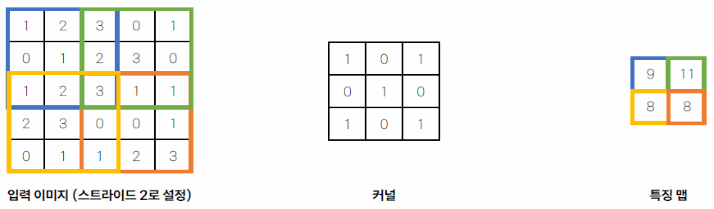

## 풀링 층(Pooling Layer)
- 풀링 층(Pooling Layer)은 합성곱신경망(CNN)에서 특징 맵의 공간적 크기를 줄여주는 역할을 하는 층
    - 신경망의 계산 복잡도를 줄이고, 과적합을 방지하며, 특정한 위치 변화에 대해 모델이 더욱 강인해지도록 함
    - 풀링 층은 입력 데이터의 중요한 정보는 유지하면서 크기를 축소하고, 연산량을 줄이기 위해 사용
- 최대 풀링(Max Pooling)은 주어진 창(window) 내에서 가장 큰 값을 선택하여 출력으로 사용
    - 주어진 창(window) 내에서 가장 큰 값을 선택하여 출력으로 사용함. 이를 통해 이미지의 특징이 강조되고, 작은 변동의 영향이 줄어듦
    - MaxPool 레이어 사용
    ```
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid')
    ```
        - `pool_size` : 풀링할 사이즈
        - `strides` : 이동 간격
        - `padding` : 패딩 추가 여부
- 평균 풀링(Average Pooling)은주어진 창 내의 값들의 평균을 계산하여 출력으로 사용
    - 지역적 정보의 평균값을 계산함으로써 전체적인 흐름이나 배경 정보를 유지하는 데 유리
    - AveragePooling 레이어 사용
    ```
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=None, padding='valid')
    ```
        - `pool_size` : 풀링할 사이즈
        - `strides` : 이동 간격
        - `padding` : 패딩 추가 여부

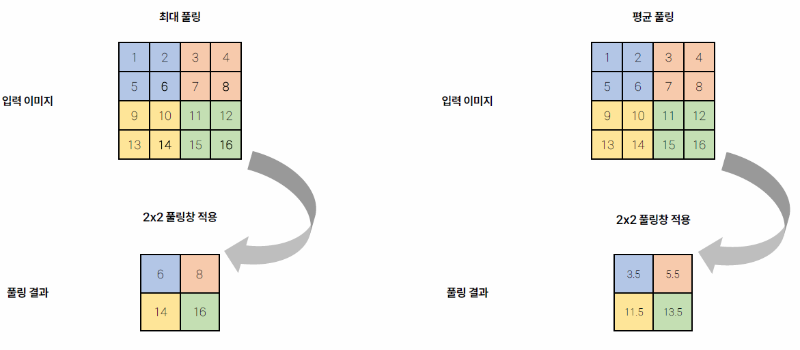

## 완전 연결 계층(Fully Connected Layer, Dense Layer)
- 완전 연결 계층은 마지막 단계에서 사용되는 층으로 합성곱 층이나 풀링 층을 통해 추출된 특징 맵을 종합하여 최종 예측 결과를 도출
    - 모든 입력 뉴런이 모든 출력 뉴런과 연결되는 구조를 가지고 있음
    - 완전 연결층은 심층신경망의 일종으로 입력값이 이미지에서 추출된 특징이라는 점이 기존 심층신경망과 차이가 있음
- 합성곱 층과 풀링 층을 사용하여 추출된 특징 맵은 주로 2D 배열(또는 텐서) 형태로 완전 연결층에 입력하기 위해선 1D 배열(또는 텐서) 형태로 변환 과정이 필요함
    - Flatten 레이어를 적용 후 Dense 레이어 사용
    ```
    tf.keras.layers.Flatten(data_format='channels_last')
    ```
        - data_format : channel정보가 위치 지정 ('channels_first')
    - Reshape 레이어를 적용 후 Dense 레이어 사용
    ```
    tf.keras.layers.Reshape(target_shape)
    ```
        - target_shape : (-1,)로 지정하여 크기가 자동계산 되도록 함
- 변환된 벡터는 여러 개의 완전 연결층을 거치며 최종적으로 출력층에 도달하며 출력층에서는 이미지가 어떤 클래스에 속하는지, 또는 어떤 값을 예측하는지 결정
    - 이미지 분류 문제에서는 시그모이드 또는 소프트맥스 활성화 함수를 통해 각 클래스에 대한 확률을 출력
    - 이미지 점수 문제에서는 활성화 함수를 사용하지 않음

####[예제] FashionMNIST 데이터 분류하기

In [5]:
# tensorflow.keras.datasets를 통해 fashion_mnist 데이터 추출
from tensorflow.keras import datasets
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import *

In [6]:
# 데이터의 크기 및 클래스의 개수 확인(채널이 1개이며, 클래스의 개수는 10개)
print(X_train.shape) # 차원이 28*28 이미지 / 60000개의 샘플수
print(X_test.shape)
print(len(np.unique(y_train)))# 클래스의 개수 # 유니크한 값이 몇개인지

# 훈련데이터의 첫번째 값 확인 (0~255의 픽셀값으로 저장됨)
X_train[0] # showdata 버튼을 누르면 데이터가 0~255의 픽셀값인것을 확인할 수 있다.

(60000, 28, 28)
(10000, 28, 28)
10


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [7]:
# X 데이터를 0~1사이값으로 변환 (X 데이터에 대하여 255로 나누기)
# 데이터가 0~255의 픽셀값으로 편차가 크기 때문에

X_train, X_test = X_train/255, X_test/255

In [8]:
# 모델 설계
# 32(CNN, ReLU) > Maxpooling > 64(CNN, ReLU) > BatchNorm > Maxpooling > 64(CNN, ReLU) > BatchNorm > Maxpooling
# > flatten > 128(ReLU) > Dropout(0.2) > 64(ReLU) > 32(ReLU) > 10(softmax)
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    layers.MaxPool2D(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax') # 10개의 클래스이니까 마지막으로 10 & softmax
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# 손실 함수 및 최적화 도구 정의 (옵티마이저는 rmsprop, loss는 sparse_categorical_crossentropy, metrics는 accuracy)
cnn.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
# 모델 학습 (epochs = 30, batch_size=256, earlyStopping 사용)
es = callbacks.EarlyStopping(monitor='loss', patience=3) # monitor='val_loss'로 바꾸며 사용가능
cnn.fit(X_train,y_train, epochs=30, batch_size=256, callbacks=[es])

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7123 - loss: 0.8359
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8723 - loss: 0.3484
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8946 - loss: 0.2868
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9079 - loss: 0.2542
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9157 - loss: 0.2277
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9200 - loss: 0.2124
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9303 - loss: 0.1921
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9309 - loss: 0.1854
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9396 - loss: 0.1644
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9395 - loss: 0.1597
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9432 - loss: 0.1520
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/st

In [11]:
# 모델 평가
cnn.evaluate(X_test, y_test)
# 정확도는 높은데 loss도 높다. 정확함 자체는 높지만!
# loss는 확률기반이기 때문, label을 정확히 예측하기는 쉽지 않았다는 것을 알 수 있음

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9151 - loss: 0.3982


[0.4036700129508972, 0.9139999747276306]

In [12]:
# 평가데이터 예측
y_pred = tf.argmax(cnn.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


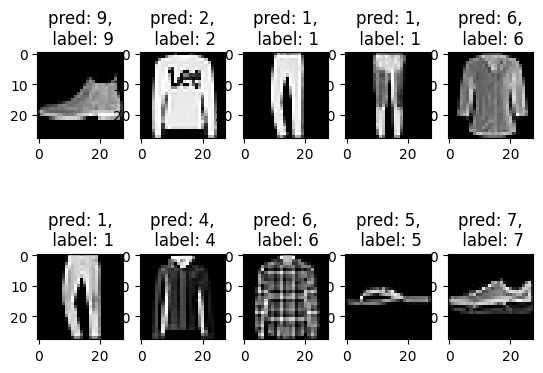

In [19]:
# 평가데이터 10개에 대하여 실제값과 예측값 표시하여 시각화
import matplotlib.pyplot as plt

for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'pred: {y_pred[i]},\n label: {y_test[i]}')

In [15]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 7, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 170,454 (665.84 KB)

 Trainable params: 85,130 (332.54 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 85,132 (332.55 KB)

## 전이학습과 미세조정
- 전이학습 (Transfer Learning)은 이미 학습된 모델을 활용하여 새로운 작업에 적응시키는 기법
- 전이학습에서 사용하는 기본 모델은 주로 대규모 데이터세트(예: ImageNet)에서 학습된 CNN 모델을 활용함
    - 기본 모델은 이미지의 저수준 특징(예: 엣지, 색상, 질감 등)부터 고수준 특징(예: 객체의 형태와 패턴)까지 잘 학습되어 있어, 이를 새로운 문제에 적용할 수 있음
- 대규모 데이터세트에서 학습된 CNN 모델(예: VGG, ResNet, Inception 등)을 선택 후 기존 모델의 가중치를 그대로 사용하고, 새로 학습할 데이터세트에서 마지막의 분류 계층만 재학습
    - 모델의 기존 계층은 새로운 데이터에서 특징을 추출하는 역할만 하며, 분류기의 가중치만 학습
- 미세조정 (Fine-Tuning)은 전이학습의 한 단계로, 기존에 학습된 모델의 일부 또는 전체 계층을 고정하지 않고, 새로운 데이터에 맞게 재학습시키는 과정
    - 새로운 데이터세트가 원래 데이터세트와 크게 다르지 않거나, 더 나은 성능이 필요할 때 주로 사용

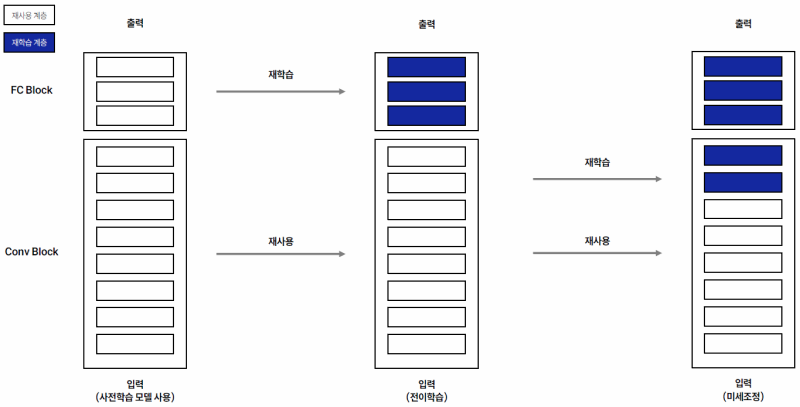

In [ ]:
# 사전학습 모델은 VGG, ResNet (VGG 많이 사용)
# FC Block  : 우리가 어떤 모델을 푸느냐에 따라 차이   -> 재학습이나 변경
# ConvBlock : 사전학습된 모델(이미지를 뽑는 것이 유리) -> 재사용
# 미세조정은 블럭 중에 선택해서 가져갈 수 있음
# 기존에 되어있는 것에 플러스하여 하는 것 -> 전이학습과 미세조정

### VGGNet
- VGGNet은 Visual Geometry Group (VGG)에서 개발한 모델로 깊이 있는 네트워크 구조(VGG16, VGG19)를 통해 이미지 인식 성능을 크게 향상
- VGGNet은 여러 개의 연속된 합성곱 층을 사용하여 고수준의 특징을 추출하여 더 깊은 네트워크가 보다 복잡한 패턴을 학습할 수
있도록 함
- 모든 합성곱 층은 3x3 필터를 사용하며, 풀링 층은 2x2 필터를 사용하는 단순한 구성 요소를 통해 네트워크의 복잡성을 줄이고 깊이를 증가시킴

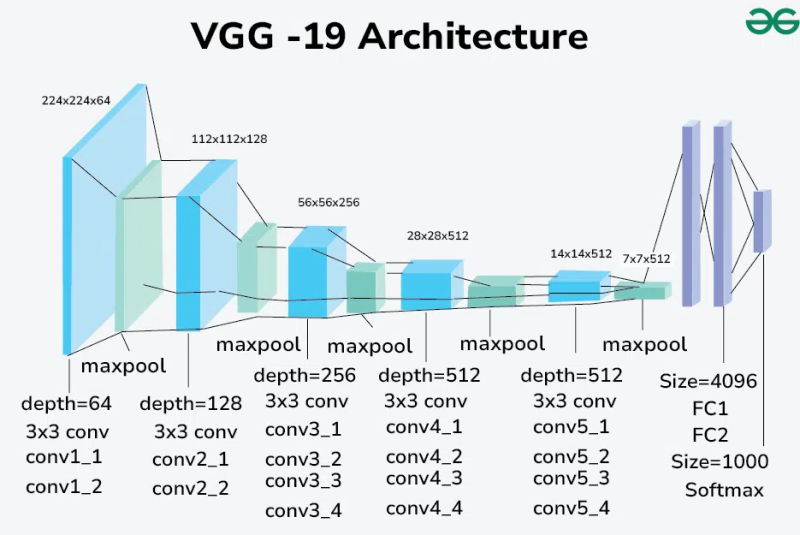

### ResNet
- ResNet (Residual Networks)은 2015년 Microsoft Research에서 발표한 딥러닝 모델로 모델의 깊이를 효율적으로 확장할 수 있도록 잔차 학습(residual learning)을 도입
- ResNet의 핵심 아이디어는 잔차 블록(Residual Block)으로 잔차 블록은 입력값을 네트워크의 여러 층을 통과시킨 후, 원래의
입력값과 더하는 구조를 가지고 있으며 skip connections 또는 shortcuts이라고도 불림 <br>
$Output = F(x) + x$ 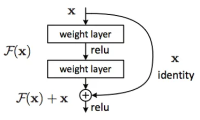
- 잔차 블록은 입력 $x$를 블록의 출력에 더하는 방식으로 학습을 용이하게 만듦
    - 깊은 네트워크에서 성능 저하 문제(Degradation Problem) 완화
- 잔차 학습을 통해 ResNet은 50, 101, 152 레이어까지 쌓아도 성능이 향상되는 것을 확인
- 잔차 블록의 기본 구성 요소는 2~3개의 3x3 합성곱 레이어를 가지고 있으며 입력값과 출력을 더하는 shortcut연결이 포함

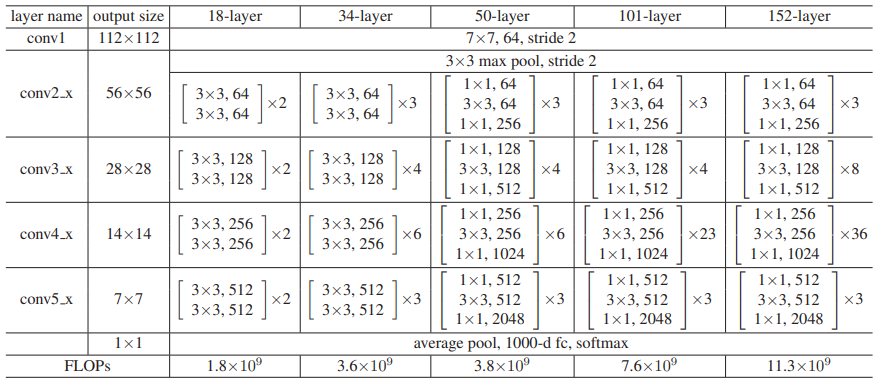

In [ ]:
# 네트워크가 깊어질수록(여러 레이어 거치면 정보가 희미해짐) 어느 한계를 못넘어가는 것을 보고 (conv 전)앞에 있는 정보를 더해줌
# 성능을 유지할 수 있도록 도와줌

In [24]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50

In [25]:
# VGG19의 전체 레이어 확인
vgg = VGG19()
vgg.summary()

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ResNet50 전체 레이어 확인
resnet = ResNet50()
resnet.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

###[예제] 사람과 말 이미지 구분

In [19]:
import tensorflow_datasets as tfds
import tensorflow as tf

# HorsesOrHumans 데이터셋 로드
dataset, info = tfds.load('horses_or_humans', with_info=True, as_supervised=True)

# 훈련 세트와 테스트 세트로 분리
train_data, test_data = dataset['train'], dataset['test']
X_train = tf.convert_to_tensor(list(train_data.map(lambda image, label: image)))
y_train = tf.convert_to_tensor(list(train_data.map(lambda image, label: label)))
X_test = tf.convert_to_tensor(list(test_data.map(lambda image, label: image)))
y_test = tf.convert_to_tensor(list(test_data.map(lambda image, label: label)))

In [20]:
X_train.shape

TensorShape([1027, 300, 300, 3])

#### 전이학습
- VGG의 Conv 블럭 그대로 사용, FC레이어 변경하여 학습

In [22]:
# 기존 모델에서 include_top=False를 사용하여 베이스 모델로 활용

# include_top -> (FC Layer)Dense Layer (Flatten~ Dense : 위에 실행한 ResNet50 전체 레이어 확인에서보면)
# summary 결과에서 Flatten~ Dense Layer가 사라진 것을 볼 수 있다.
# -> include_top false로 했기 때문

# input_shape=(300,300,3) 위와 같이
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(300,300,3))

# base_model은 학습하지 않도록 설정 (conv블럭 학습 false 지정)/ weight 사용하지않고 'imagenet'의 weight를 사용하겠다.
base_model.trainable= False
# summary 결과에서 전체가 다 Non-trainable 로 바뀜

base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 300, 300, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 300, 300, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 150, 150, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 150, 150, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 75, 75, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 75, 75, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 37, 37, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 37, 37, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 18, 18, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [23]:
from tensorflow.keras import layers, models
# # 기존 모델에서 include_top=False를 사용하여 베이스 모델로 활용
# base_model = VGG19(weights='imagenet', include_top=False, input_shape=(300,300,3))

# # base_model은 학습하지 않도록 설정 (conv블럭 학습 false 지정)
# base_model.trainable= False

# FC레이어 변경

# !!!위에서 포함하지 않은 것 다시 추가
# base_model.output을 기반으로 Flatten
# 우리의 기존 vgg는 (224, 224, 3) 으로 input_layer가 정해져 있음.
# 위에서 바꾼 input_shape(300, 300, 3)에 맞춰서 (base_model을 통과하면 (300, 300, 3)통과하는 아웃풋이 나옴)

x = layers.Flatten()(base_model.output)  # base_model의 마지막 feature map을 flatten
x = layers.Dense(1024, activation='relu')(x) # x(output)에 대해여 dense를 적용해라
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(1, activation='sigmoid')(x) # 0아니면 1로 나와야하는 모델인데 실제 값은 y_train자체가 하나의 차원을 가지고 있기 때문에 sigmoid로 분류
                                             # 마지막 레이어는 무조건 우리 문제에 맞춰서 sigmoid로 바꿔줘야한다.

# base_model을 기준으로 모델 만들기
# 우리가 베이스 모델에 인풋을 넣고 베이스모델을 통과해서 변경된 FC레이어에 넣어 적용해 마지막으로 x가 아웃풋으로 나오는 모델임을 정의함
model = models.Model(inputs=base_model.input, outputs=x) # input은 base_model/ output은 x

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(X_train, y_train, epochs=10, verbose=0)

# 모델 요약
# model.summary()

# 모델 평가
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 419ms/step - accuracy: 1.0000 - loss: 0.0000e+00


[0.0, 1.0]

#### 미세조정
- Conv 블럭 중 block5에 대하여 학습하도록 설정

In [ ]:
# 위에 표를 보면 block5_conv 되어있음 그중에 5번을 다시 학습하겠다.
# 원래는 trainable = False를 해서 학습을 중지했는데
# 그것에 대해 다시 trainable을 true로 만들어주고

In [27]:
# 기존 모델에서 include_top=False를 사용하여 베이스 모델로 활용
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(300,300,3))

# base_model은 학습하지 않도록 설정 (conv블럭 학습 false 지정)
base_model.trainable= False

# block5레이어 학습하도록 재설정
layer_names = ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_conv4']
for layer in base_model.layers:
    if layer.name in layer_names:
        layer.trainable = True

#위의 for문이랑 똑같이 동작 / 위처럼 이름을 넣어도 되고 그중에 일부로
# for layer in base_model.layers[-5:]:
#     layer.trainable = True

# Fully Connected layer 추가
x = layers.Flatten()(base_model.output)  # base_model의 마지막 output(feature map)을 flatten
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(1, activation='sigmoid')(x)

# base_model을 기준으로 모델 만들기
model = models.Model(inputs=base_model.input, outputs=x)

# 손실 함수 및 최적화 도구 정의
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(X_train, y_train, epochs=10, verbose=0)

# 모델 평가
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 413ms/step - accuracy: 0.4929 - loss: 0.6934


[0.6932122111320496, 0.5]

In [28]:
# 모델 요약
model.summary()

# Trainable params: 30,673,921 (117.01 MB) 결과를 보면
# 밑에 5번 만 트레인이 되고 나머지는 안되었다고 볼 수 있다.

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 300, 300, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 300, 300, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 150, 150, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 150, 150, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 75, 75, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 75, 75, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 75, 75, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 37, 37, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 37, 37, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 37, 37, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 18, 18, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 102,606,917 (391.41 MB)

 Trainable params: 30,673,921 (117.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 61,347,844 (234.02 MB)

- CNN (이미지에 특화된 Newrun Network)
  : 하나의 이미지를 필터(커널)을 가지고 특징을 합성곱을 이용해 추출(Conv)하고 주요정보 Pooling( 뽑아내고) 1차원으로 변경해서 (Flatten) 그것을 Fully Connected Dense 로 분석/학습(분류와 예측)<br>
  --> 머신러닝은 우리가 정보를 넣어서 분석 학습을 하는 것이었다면 딥러닝은 특징 추출도 이 알고리즘이 한다. <br>
  CNN 구성시 레이어에 따라 결과가 달라짐.<br>
  VGG 는 conv연달아 쓰고 pooling을 했더니 효과가 좋다. relu()를 함께 쓰므로서 중요하지 않은 정보가 날라감. 기존보다 더 작은 값을 가져감<br>
  ResNet 는 레이어를 쌓아갈 수록 성능이 더 좋아지는 것은 아니다. 잔차를 하나의 블락 뒤에 더해준다 -> 특징을 잘 못뽑더라도 기존의 것을 보존할 수 있다.<br>
  이렇게 만들어진  VGG, ResNet을 가지고 우리는 이 모델을 재사용을 할 수 있다.
  재사용시 FC레이어(일부레이어) 재학습 : 전이학습/미세조정<br>, ConV는 재사용한다.

#[실습] cifar10 데이터셋 분류

## 1. cnn 모델 학습

In [47]:
# 데이터 로드
import numpy as np
from tensorflow.keras import *
(X_train, y_train), (X_data, y_data) = datasets.cifar10.load_data()

train 크기 (50000, 32, 32, 3)
test 크기 (2000, 32, 32, 3)
클래스 개수 10


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
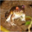

In [48]:
print("train 크기", X_train.shape)
print("test 크기", X_test.shape)
print("클래스 개수", len(np.unique(y_test)))
X_train[0]

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, stratify=y_data, test_size=0.2, random_state=0)
print("train 크기", X_train.shape)
print("test 크기", X_test.shape)
print("클래스 개수", len(np.unique(y_test)))

train 크기 (8000, 32, 32, 3)
test 크기 (2000, 32, 32, 3)
클래스 개수 10


In [58]:
# X 데이터를 0~1사이값으로 변환 (X 데이터에 대하여 255로 나누기)
X_train, y_train = X_train/255, y_train/255

In [59]:
# cnn 모델 설계
# input > 32(Conv2d(5) 이미지 크기 유지) > ReLU > Maxpooling > 32(Conv2d(5) 이미지 크기 유지) > ReLU > Maxpooling
# > Flatten > 1024(ReLU) > Dropout(0.5) > output(?)
cnn = models.Sequential([
    layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPool2D(),
    layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
# 손실 함수 및 최적화 도구 정의 (optimizser, loss, metrics는 문제 기반하여 선택)
cnn.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [64]:
# 모델 학습
es = callbacks.EarlyStopping(monitor='val_loss', patience = 3)
cnn.fit(X_train, y_train, epochs=100, batch_size=256, callbacks=[es])

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.0988 - loss: 1.6211e-08
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1036 - loss: 5.9517e-09
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1028 - loss: 3.6098e-10
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0976 - loss: 1.0194e-09
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1055 - loss: 7.4830e-11
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0969 - loss: 9.4889e-10
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1058 - loss: 6.2323e-10
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0970 - loss: 3.2490e-11
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0992 - loss: 1.8527e-10
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0980 - loss: 1.2092e-09
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0948 - loss: 6.0399e-10
Epoch 12

In [65]:
# 모델 평가
cnn.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0862 - loss: 14894.5684


[14632.6630859375, 0.10000000149011612]

In [ ]:
cnn.summary()

## 전이학습
- 대규모학습모델(VGG19, ResNet50) 중 택하여 conv 블럭 학습 중지

In [71]:
# 대규모 학습 모델 Freeze
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(32,32,3))

# base_model은 학습하지 않도록 설정 (conv블럭 학습 false 지정)
base_model.trainable= False

base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [72]:
# 새롭게 추가할 layer 구성
from tensorflow.keras import layers, models

x = layers.Flatten()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(1, activation='sigmoid')(x)

In [73]:
# 손실 함수 및 최적화 도구 정의
# base_model 기준 모델 만들기
model = models.Model(inputs=base_model.input, outputs=x)

model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])

In [74]:
# 모델 학습
model.fit(X_train,y_train, epochs=30, verbose=0)

In [75]:
# 모델 평가
model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0862 - loss: 960.4597


[962.47216796875, 0.10000000149011612]

## 미세조정
- 전이학습한 모델에 대하여 일부 conv 블럭 학습으로 재설정하여 학습

In [76]:
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(32,32,3))

base_model.trainable= False

for layer in base_model.layers[-5:]:
    layer.trainable = True

x = layers.Flatten()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=x)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, verbose=0)

model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0862 - loss: 394.0566


[386.8294677734375, 0.10000000149011612]

In [ ]:
model.summary()

### 풀이

In [ ]:
# X 데이터를 0~1사이값으로 변환 (X 데이터에 대하여 255로 나누기)
X_train, X_test = X_train/255, X_test/255

In [ ]:
# cnn 모델 설계
# input > 32(Conv2d(5) 이미지 크기 유지) > ReLU > Maxpooling > 32(Conv2d(5) 이미지 크기 유지) > ReLU > Maxpooling
# > Flatten > 1024(ReLU) > Dropout(0.5) > output(?)
import tensorflow as tf
class CNN(tf.keras.Model):
    def __init__(self, shape=(32,32,3), num_class=10):
        super(CNN, self).__init__()
        self.conv1 = layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=shape)
        self.conv2 = layers.Conv2D(32, (5,5), padding='same', activation='relu')
        self.maxpool = layers.MaxPool2D()
        self.flatten = layers.Flatten()
        self.fc = layers.Dense(1024, activation='relu')
        self.dropout = layers.Dropout(0.5)
        if num_class <=2 :
            self.out_layer = layers.Dense(num_class, activation='sigmoid')
        else:
            self.out_layer = layers.Dense(num_class, activation='softmax')

    def call(self, x):
        out = self.maxpool(self.conv1(x))
        out = self.maxpool(self.conv2(out))
        out = self.flatten(out)
        out = self.fc(out)
        out = self.dropout(out)
        out = self.out_layer(out)
        return out

In [ ]:
cnn = CNN((32,32,3), 10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 손실 함수 및 최적화 도구 정의 (optimizser, loss, metrics는 문제 기반하여 선택)
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 모델 학습
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2399 - loss: 2.0540
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4432 - loss: 1.5530
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5205 - loss: 1.3173
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5970 - loss: 1.1124
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6569 - loss: 0.9630
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7300 - loss: 0.7718
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8099 - loss: 0.5536
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8742 - loss: 0.3766
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9358 - loss: 0.2079
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9680 - loss: 0.1222


In [ ]:
# 모델 평가
cnn.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5323 - loss: 2.2809


[2.3523056507110596, 0.5285000205039978]

#### 전이학습

In [ ]:
# 대규모 학습 모델 Freeze
from tensorflow.keras.applications import VGG19

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(32,32,3))
# base_model.summary()

In [ ]:
# 새롭게 추가할 layer 구성
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
# 손실 함수 및 최적화 도구 정의
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 모델 학습
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.3337 - loss: 1.8767
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4940 - loss: 1.4437
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5064 - loss: 1.3742
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5315 - loss: 1.3230
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5507 - loss: 1.2720
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5681 - loss: 1.2377
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5761 - loss: 1.1964
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5916 - loss: 1.1555
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6162 - loss: 1.1101
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6074 - loss: 1.0953


In [ ]:
# 모델 평가
model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.5389 - loss: 1.3208


[1.2982594966888428, 0.5394999980926514]

#### 미세조정

In [ ]:
for layer in base_model.layers[-5:]:
    layer.trainable = True

model_t = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model_t.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_t.fit(X_train, y_train, epochs=10)

model_t.evaluate(X_test, y_test)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.1011 - loss: 2.3423
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.0961 - loss: 2.3026
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.0988 - loss: 2.3030
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.0959 - loss: 2.3027
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.1042 - loss: 2.3026
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.1047 - loss: 2.3027
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.1010 - loss: 2.3027
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.0969 - loss: 2.3027
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.0941 - loss: 2.3028
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.0972 - loss: 2.3027
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0862 - loss: 2.3026


[2.3025951385498047, 0.10000000149011612]